# ST-GCN - input stream comparison, with proper reproducibility

Same joint / bone / joint_bone comparison as before, with one fix: the previous run's `joint` config was supposed to be identical to the earlier `weight_decay_only` result (same seed, same everything), but scored meaningfully differently - 70.08% vs 71.48% top-1. The cause: `DataLoader(num_workers=4, ...)` spawns separate worker processes for loading and augmenting data, and each worker gets its own internal randomness for things like augmentation's rotation angles, jitter noise, and mirror coin-flips. `torch.manual_seed()` alone doesn't reach into those worker processes without an explicit `worker_init_fn` - so "seed=42" has only been partially reproducible all day: model init and batch order were fixed, but the exact realized augmentation per epoch wasn't.

This adds the standard PyTorch fix - a seeded `worker_init_fn` plus a dedicated `torch.Generator` passed to the training DataLoader - so re-running the same seed now actually reproduces the same result, and the joint/bone/joint_bone comparison can be trusted properly rather than being partly noise.

### determinism - before torch touches CUDA

In [1]:
import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score, top_k_accuracy_score,
    confusion_matrix, precision_recall_fscore_support,
)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

sys.path.insert(0, "/workspace/badminton-honours-project")
import dataset as ds

import mmaction.models  # noqa: F401
from mmaction.utils import register_all_modules
register_all_modules()
from mmaction.registry import MODELS

from clearml import Task

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda:0


### the DataLoader worker-seeding fix

Standard PyTorch reproducibility recipe: `seed_worker` re-seeds numpy and Python's `random` module inside each worker process using a value derived from torch's per-worker seed, and a dedicated `torch.Generator` controls the DataLoader's own shuffling/sampling randomness independently of the global RNG state.

In [2]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


### paths

In [3]:
OUT_ROOT = "/workspace/outputs/stgcn_bone_stream_v2"
CKPT_ROOT = "/workspace/checkpoints/stgcn_bone_stream_v2"
os.makedirs(OUT_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)


### data - advanced augmentation, matching the winning recipe

In [4]:
manifest = ds.load_filtered_manifest(
    "/workspace/data/split_manifest.csv",
    "/workspace/data/extraction_log.csv",
)

class_names = sorted(manifest["class_name"].unique())
class_to_id = {name: i for i, name in enumerate(class_names)}
num_classes = len(class_names)

train_manifest = manifest[manifest["split"] == "train"].reset_index(drop=True)
val_manifest = manifest[manifest["split"] == "val"].reset_index(drop=True)
test_manifest = manifest[manifest["split"] == "test"].reset_index(drop=True)

KEYPOINTS_ROOT = "/workspace/data/keypoints_smoothed"

train_ds = ds.BadmintonPoseDataset(train_manifest, KEYPOINTS_ROOT, class_to_id, augmentation_policy="advanced")
val_ds = ds.BadmintonPoseDataset(val_manifest, KEYPOINTS_ROOT, class_to_id)
test_ds = ds.BadmintonPoseDataset(test_manifest, KEYPOINTS_ROOT, class_to_id)

balanced_sampler = ds.build_class_balanced_sampler(train_manifest, target_per_class=500, seed=42)

val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"{num_classes} classes, train {len(train_manifest)}, val {len(val_ds)}, test {len(test_ds)}")


dropped 4 manually-excluded clips from the manifest (7814 remain)
18 classes, train 6251, val 781, test 782


### batch -> ST-GCN input, parameterized by stream

Uses only the two dict keys confirmed to exist by the grep before writing this: `batch["keypoints"]` (T,17,3) and `batch["bone"]` (T,17,2).

In [5]:
STREAM_CHANNELS = {"joint": 3, "bone": 2, "joint_bone": 5}


def batch_to_stgcn_input(batch, stream):
    if stream == "joint":
        x = batch["keypoints"].float()
    elif stream == "bone":
        x = batch["bone"].float()
    elif stream == "joint_bone":
        x = torch.cat([batch["keypoints"].float(), batch["bone"].float()], dim=-1)
    else:
        raise ValueError(f"unknown stream: {stream}")
    return x.unsqueeze(1).unsqueeze(1)   # (N, num_clips=1, M=1, T, V, C)


### SMOKE TEST - verify all three stream shapes before training anything

In [6]:
smoke_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
smoke_batch = next(iter(smoke_loader))

print("raw batch[\"keypoints\"] shape:", smoke_batch["keypoints"].shape)
print("raw batch[\"bone\"] shape:", smoke_batch["bone"].shape)
print()

for stream, expected_c in STREAM_CHANNELS.items():
    x = batch_to_stgcn_input(smoke_batch, stream)
    actual_c = x.shape[-1]
    status = "OK" if actual_c == expected_c else "MISMATCH"
    print(f"{stream:12s} shape={tuple(x.shape)}  expected_channels={expected_c}  actual={actual_c}  [{status}]")
    assert actual_c == expected_c, f"{stream}: channel mismatch"

print()
print("all three stream shapes verified correct")


raw batch["keypoints"] shape: torch.Size([4, 30, 17, 3])
raw batch["bone"] shape: torch.Size([4, 30, 17, 2])

joint        shape=(4, 1, 1, 30, 17, 3)  expected_channels=3  actual=3  [OK]
bone         shape=(4, 1, 1, 30, 17, 2)  expected_channels=2  actual=2  [OK]
joint_bone   shape=(4, 1, 1, 30, 17, 5)  expected_channels=5  actual=5  [OK]

all three stream shapes verified correct


### metrics, including per-class breakdown for the ClearML table/confusion matrix

In [7]:
@torch.no_grad()
def evaluate(model, loader, stream):
    model.eval()
    all_labels, all_preds, all_probs = [], [], []

    for batch in loader:
        x = batch_to_stgcn_input(batch, stream).to(device)
        y = batch["label"].to(device)
        logits = model(x, mode="tensor", stage="head")
        probs = torch.softmax(logits, dim=1)

        all_labels.append(y.cpu().numpy())
        all_preds.append(probs.argmax(dim=1).cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    labels = np.concatenate(all_labels)
    preds = np.concatenate(all_preds)
    probs = np.concatenate(all_probs)

    return {
        "top1": accuracy_score(labels, preds),
        "top5": top_k_accuracy_score(labels, probs, k=5, labels=list(range(num_classes))),
        "mca": balanced_accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "labels": labels, "preds": preds,
    }


### the reusable training function - now with seeded workers

`worker_init_fn=seed_worker` and a dedicated `torch.Generator` are passed to the training DataLoader specifically - that's the one using augmentation and multiple workers. val/test loaders don't need this (no augmentation, `shuffle=False`, order already fixed).

In [8]:
def train_one_stream(stream, seed=42, num_epochs=60, patience=20, batch_size=16,
                      lr=0.01, weight_decay=1e-3):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    in_channels = STREAM_CHANNELS[stream]

    model_cfg = dict(
        type="RecognizerGCN",
        backbone=dict(
            type="STGCN",
            graph_cfg=dict(layout="coco", mode="stgcn_spatial"),
            in_channels=in_channels, base_channels=64, ch_ratio=2,
            num_stages=9, inflate_stages=[4, 7], down_stages=[4, 7],
        ),
        cls_head=dict(type="GCNHead", num_classes=num_classes, in_channels=256,
                      loss_cls=dict(type="CrossEntropyLoss")),
    )
    model = MODELS.build(model_cfg).to(device)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(seed)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, sampler=balanced_sampler,
        num_workers=4, pin_memory=True, persistent_workers=True,
        worker_init_fn=seed_worker, generator=loader_generator,
    )

    task = Task.init(project_name="BadmintonPoseAnalysis", task_name=f"stgcn_stream_v2_{stream}", reuse_last_task_id=False)
    logger = task.get_logger()
    task.connect({
        "stream": stream, "in_channels": in_channels, "seed": seed,
        "lr": lr, "weight_decay": weight_decay, "num_epochs": num_epochs,
        "batch_size": batch_size, "schedule": "StepLR", "augmentation_policy": "advanced",
        "worker_seeding_fix": True,
    })

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_top1 = 0.0
    epochs_without_improvement = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_labels, epoch_preds = [], []

        for batch in train_loader:
            x = batch_to_stgcn_input(batch, stream).to(device)
            y = batch["label"].to(device)

            optimizer.zero_grad()
            logits = model(x, mode="tensor", stage="head")
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * x.size(0)
            epoch_labels.append(y.cpu().numpy())
            epoch_preds.append(logits.argmax(dim=1).cpu().numpy())

        scheduler.step()

        train_loss = epoch_loss / len(train_loader.dataset)
        train_acc = accuracy_score(np.concatenate(epoch_labels), np.concatenate(epoch_preds))
        val_metrics = evaluate(model, val_loader, stream)

        logger.report_scalar("loss", "train", train_loss, iteration=epoch)
        logger.report_scalar("accuracy", "train", train_acc, iteration=epoch)
        logger.report_scalar("accuracy", "val_top1", val_metrics["top1"], iteration=epoch)
        logger.report_scalar("accuracy", "val_mca", val_metrics["mca"], iteration=epoch)

        if val_metrics["top1"] > best_val_top1:
            best_val_top1 = val_metrics["top1"]
            epochs_without_improvement = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"[{stream}] epoch {epoch:3d}  train_acc={train_acc:.4f}  "
                  f"val_top1={val_metrics['top1']:.4f}  val_mca={val_metrics['mca']:.4f}")

        if epochs_without_improvement >= patience:
            print(f"[{stream}] early stopping at epoch {epoch}, best val_top1={best_val_top1:.4f}")
            break

    model.load_state_dict(best_state)

    train_final = evaluate(model, DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=4, pin_memory=True), stream)
    test_final = evaluate(model, test_loader, stream)

    metrics = {
        "stream": stream,
        "train_acc": train_final["top1"],
        "test_top1": test_final["top1"],
        "test_top5": test_final["top5"],
        "test_mca": test_final["mca"],
        "test_macro_f1": test_final["macro_f1"],
        "train_test_gap": train_final["top1"] - test_final["top1"],
    }

    for metric_name in ["train_acc", "test_top1", "test_top5", "test_mca", "test_macro_f1", "train_test_gap"]:
        logger.report_single_value(name=metric_name, value=metrics[metric_name])

    cm = confusion_matrix(test_final["labels"], test_final["preds"], labels=list(range(num_classes)))
    logger.report_confusion_matrix(
        title="Test Confusion Matrix", series=stream,
        matrix=cm, xaxis="Predicted", yaxis="Actual",
        xlabels=class_names, ylabels=class_names,
    )

    precision, recall, f1, support = precision_recall_fscore_support(
        test_final["labels"], test_final["preds"], labels=list(range(num_classes)), zero_division=0,
    )
    per_class_df = pd.DataFrame({
        "class": class_names, "precision": precision, "recall": recall,
        "f1": f1, "support": support,
    })
    logger.report_table(title="Per-Class Test Metrics", series=stream, table_plot=per_class_df)

    ckpt_path = os.path.join(CKPT_ROOT, f"stream_{stream}_best.pt")
    torch.save(model.state_dict(), ckpt_path)
    task.upload_artifact("checkpoint", ckpt_path)
    per_class_df.to_csv(os.path.join(OUT_ROOT, f"per_class_{stream}.csv"), index=False)
    task.close()

    return metrics, per_class_df


### run all three streams

Same 3x-a-single-run cost as before. This time the numbers should actually be reproducible if re-run with the same seed - worth spot-checking later if it matters for the thesis.

In [9]:
streams_to_test = ["joint", "bone", "joint_bone"]

all_results = {}
all_per_class = {}

for stream in streams_to_test:
    print(f"\n=== training stream={stream} ===")
    metrics, per_class_df = train_one_stream(stream)
    all_results[stream] = metrics
    all_per_class[stream] = per_class_df
    print(f"[{stream}] FINAL: test_top1={metrics['test_top1']:.4f}  gap={metrics['train_test_gap']:.4f}  "
          f"test_mca={metrics['test_mca']:.4f}  test_macro_f1={metrics['test_macro_f1']:.4f}")



=== training stream=joint ===
ClearML Task: created new task id=f3b0a93c397e4140bc4f4bf4a1c85135
2026-09-10 07:42:56,498 - clearml.Repository Detection - WARNING - Failed accessing the jupyter server(s): []
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/f3b0a93c397e4140bc4f4bf4a1c85135/output/log
[joint] epoch   0  train_acc=0.3015  val_top1=0.5608  val_mca=0.4357
[joint] epoch  10  train_acc=0.8154  val_top1=0.6786  val_mca=0.6437
[joint] epoch  20  train_acc=0.9373  val_top1=0.7004  val_mca=0.6312
[joint] epoch  30  train_acc=0.9576  val_top1=0.7170  val_mca=0.6283
[joint] epoch  40  train_acc=0.9598  val_top1=0.7106  val_mca=0.6205
[joint] early stopping at epoch 46, best val_top1=0.7234


███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  8.02MB/s]: 


[joint] FINAL: test_top1=0.7110  gap=0.2599  test_mca=0.6121  test_macro_f1=0.6289

=== training stream=bone ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=07e77ed092d547d4918a92d819db2eb8
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/07e77ed092d547d4918a92d819db2eb8/output/log
[bone] epoch   0  train_acc=0.2248  val_top1=0.4059  val_mca=0.2819
[bone] epoch  10  train_acc=0.7044  val_top1=0.6735  val_mca=0.6025
[bone] epoch  20  train_acc=0.8464  val_top1=0.6914  val_mca=0.6169
[bone] epoch  30  train_acc=0.8762  val_top1=0.6940  val_mca=0.6350
[bone] epoch  40  train_acc=0.8807  val_top1=0.6940  val_mca=0.6391
[bone] epoch  50  train_acc=0.8829  val_top1=0.6914  val_mca=0.6234
[bone] epoch  59  train_acc=0.8826  val_top1=0.6965  val_mca=0.6344


...

[bone] FINAL: test_top1=0.6867  gap=0.2013  test_mca=0.5774  test_macro_f1=0.5889

=== training stream=joint_bone ===


Failed accessing the jupyter server(s): []


ClearML Task: created new task id=002e52e56f124bd690e7771348bd3233
ClearML results page: https://app.clear.ml/projects/89838577f7964905a3b492353933fcb2/tasks/002e52e56f124bd690e7771348bd3233/output/log
[joint_bone] epoch   0  train_acc=0.2996  val_top1=0.4520  val_mca=0.3542
[joint_bone] epoch  10  train_acc=0.7690  val_top1=0.7055  val_mca=0.6523
[joint_bone] epoch  20  train_acc=0.8937  val_top1=0.7273  val_mca=0.6447
[joint_bone] epoch  30  train_acc=0.9236  val_top1=0.7298  val_mca=0.6392
[joint_bone] epoch  40  train_acc=0.9257  val_top1=0.7311  val_mca=0.6467
[joint_bone] epoch  50  train_acc=0.9241  val_top1=0.7298  val_mca=0.6372
[joint_bone] epoch  59  train_acc=0.9233  val_top1=0.7273  val_mca=0.6393
[joint_bone] early stopping at epoch 59, best val_top1=0.7478


███████████████████████████████ 100% | 11.66/11.66 MB [00:01<00:00,  7.68MB/s]: 


[joint_bone] FINAL: test_top1=0.7263  gap=0.2186  test_mca=0.6360  test_macro_f1=0.6479


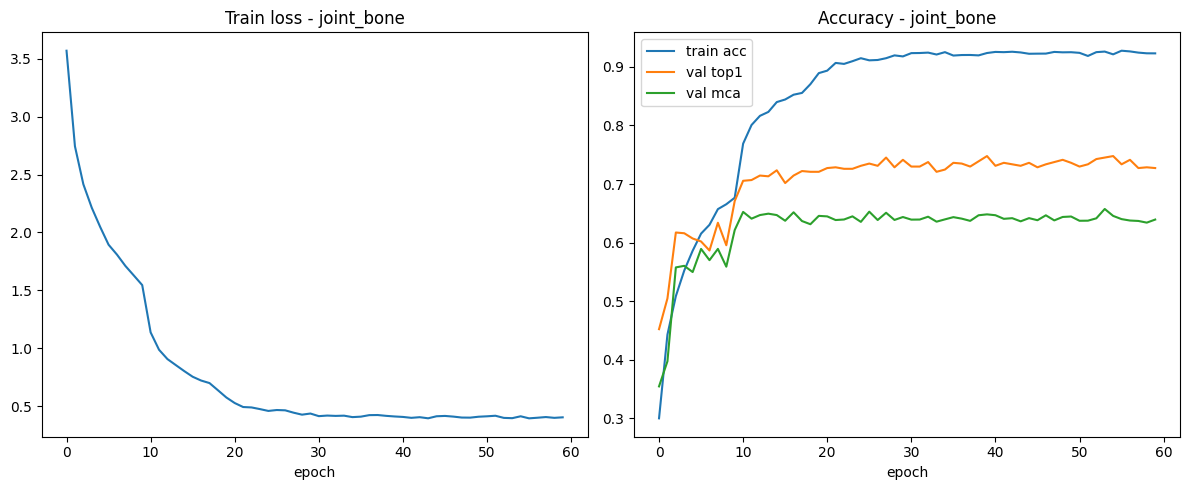

In [12]:
from clearml import Task
import matplotlib.pyplot as plt

task = Task.get_task(project_name="BadmintonPoseAnalysis", task_name="stgcn_stream_v2_joint_bone")
scalars = task.get_reported_scalars()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

loss = scalars["loss"]["train"]
axes[0].plot(loss["x"], loss["y"])
axes[0].set_title("Train loss - joint_bone")
axes[0].set_xlabel("epoch")

train_acc = scalars["accuracy"]["train"]
val_acc = scalars["accuracy"]["val_top1"]
val_mca = scalars["accuracy"]["val_mca"]
axes[1].plot(train_acc["x"], train_acc["y"], label="train acc")
axes[1].plot(val_acc["x"], val_acc["y"], label="val top1")
axes[1].plot(val_mca["x"], val_mca["y"], label="val mca")
axes[1].set_title("Accuracy - joint_bone")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

### comparison table

In [10]:
LI_ET_AL_BENCHMARK = {"stream": "Li et al. benchmark (single model)", "test_top1": 0.7441,
                      "test_top5": 0.9376, "test_mca": 0.6144, "test_macro_f1": None, "train_test_gap": None}
PREVIOUS_UNSEEDED_RUN = {"stream": "joint (previous, unseeded workers)", "test_top1": 0.7008,
                         "test_top5": 0.9322, "test_mca": 0.5938, "test_macro_f1": 0.6159, "train_test_gap": 0.2776}

comparison = pd.DataFrame(list(all_results.values()) + [PREVIOUS_UNSEEDED_RUN, LI_ET_AL_BENCHMARK]).set_index("stream")
comparison = comparison[["train_acc", "test_top1", "train_test_gap", "test_top5", "test_mca", "test_macro_f1"]]
comparison.to_csv(os.path.join(OUT_ROOT, "stream_comparison_v2.csv"))
comparison


,train_acc,test_top1,train_test_gap,test_top5,test_mca,test_macro_f1
stream,,,,,,
joint,0.970885,0.710997,0.259887,0.942455,0.612096,0.628895
bone,0.888018,0.686701,0.201317,0.925831,0.577432,0.588947
joint_bone,0.944969,0.726343,0.218626,0.941176,0.636019,0.647917
"joint (previous, unseeded workers)",NaN,0.700800,0.277600,0.932200,0.593800,0.615900
Li et al. benchmark (single model),NaN,0.744100,NaN,0.937600,0.614400,NaN


---

Compare the new `joint` row against `joint (previous, unseeded workers)` first - if they're now close, the worker-seeding fix is doing its job and this comparison can be trusted. Then read `bone` vs `joint_bone` vs `joint` properly, knowing the numbers reflect the actual streams being tested rather than partly-uncontrolled augmentation randomness.